In [1]:
# Install required libraries
!pip install sentence-transformers scikit-learn seaborn matplotlib

In [2]:
# Import all required libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
# 10 sentences across 3 topics
# Cricket (4 sentences), Cooking (3 sentences), Cybersecurity (3 sentences)

sentences = [
    # Cricket
    "The batsman hit a brilliant six over the boundary",
    "India won the match by taking three wickets in the final over",
    "The spinner bowled a perfect googly to dismiss the opener",
    "The cricket team celebrated their victory in the World Cup",

    # Cooking
    "Add a pinch of salt and pepper to the boiling pasta",
    "Preheat the oven to 180 degrees before baking the cake",
    "Saute the onions in olive oil until they turn golden brown",

    # Cybersecurity
    "The hacker used a phishing email to steal login credentials",
    "Always use a strong password and enable two factor authentication",
    "The firewall blocked the suspicious network traffic successfully"
]

# Labels for the heatmap
labels = [
    "Cricket 1", "Cricket 2", "Cricket 3", "Cricket 4",
    "Cooking 1", "Cooking 2", "Cooking 3",
    "Cyber 1",   "Cyber 2",   "Cyber 3"
]

print(f"Total sentences: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"{i+1}. {s}")

Total sentences: 10
1. The batsman hit a brilliant six over the boundary
2. India won the match by taking three wickets in the final over
3. The spinner bowled a perfect googly to dismiss the opener
4. The cricket team celebrated their victory in the World Cup
5. Add a pinch of salt and pepper to the boiling pasta
6. Preheat the oven to 180 degrees before baking the cake
7. Saute the onions in olive oil until they turn golden brown
8. The hacker used a phishing email to steal login credentials
9. Always use a strong password and enable two factor authentication
10. The firewall blocked the suspicious network traffic successfully


In [4]:
# Load the sentence transformer model
print("Loading model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for all 10 sentences
print("Generating embeddings...")
embeddings = model.encode(sentences)

print(f"\nEmbedding shape: {embeddings.shape}")
print(f"Each sentence is represented as {embeddings.shape[1]} numbers")

Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings...

Embedding shape: (10, 384)
Each sentence is represented as 384 numbers


In [5]:
# Compute 10x10 cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

print("10x10 Cosine Similarity Matrix:")
print(np.round(similarity_matrix, 2))

10x10 Cosine Similarity Matrix:
[[ 1.    0.46  0.45  0.36 -0.02  0.05  0.04  0.03  0.03  0.11]
 [ 0.46  1.    0.35  0.58  0.01  0.02  0.09  0.03 -0.    0.12]
 [ 0.45  0.35  1.    0.25  0.06  0.04  0.13  0.04  0.02  0.15]
 [ 0.36  0.58  0.25  1.   -0.04  0.    0.03 -0.02 -0.05  0.02]
 [-0.02  0.01  0.06 -0.04  1.    0.1   0.31  0.02  0.05  0.09]
 [ 0.05  0.02  0.04  0.    0.1   1.    0.23  0.12  0.02  0.03]
 [ 0.04  0.09  0.13  0.03  0.31  0.23  1.    0.05  0.05  0.  ]
 [ 0.03  0.03  0.04 -0.02  0.02  0.12  0.05  1.    0.35  0.32]
 [ 0.03 -0.    0.02 -0.05  0.05  0.02  0.05  0.35  1.    0.1 ]
 [ 0.11  0.12  0.15  0.02  0.09  0.03  0.    0.32  0.1   1.  ]]


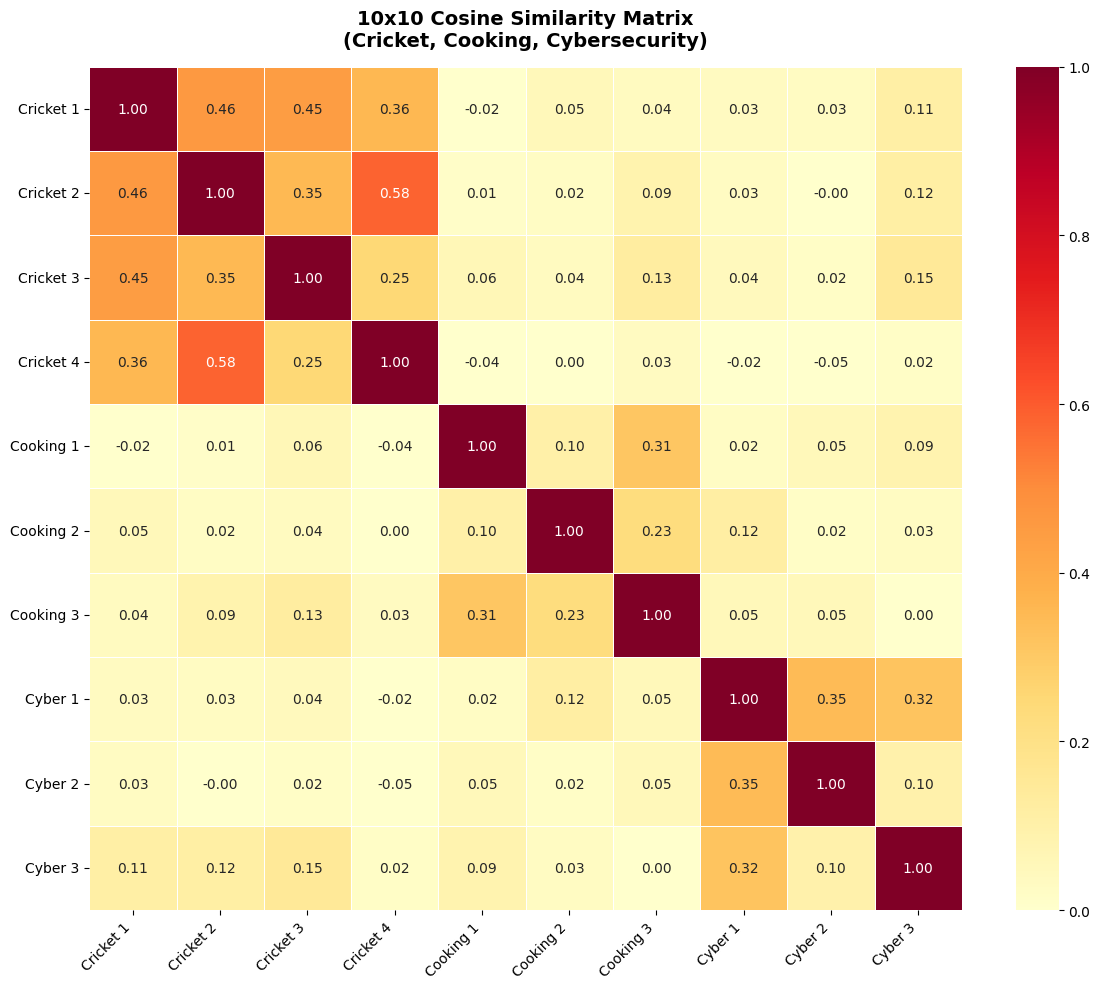

Heatmap saved!


In [6]:
# Display similarity matrix as a heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=labels,
    yticklabels=labels,
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("10x10 Cosine Similarity Matrix\n(Cricket, Cooking, Cybersecurity)",
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

print("Heatmap saved!")

In [7]:
# Given query sentence
query = "The bowler took three wickets in one over"

print(f"Query: '{query}'\n")

# Generate embedding for the query
query_embedding = model.encode([query])

# Compute similarity between query and all 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Pair each sentence with its similarity score
scored = list(zip(sentences, query_similarities))

# Sort by similarity score descending
scored_sorted = sorted(scored, key=lambda x: x[1], reverse=True)

# Print top 2 most similar sentences
print("Top 2 Most Similar Sentences:")
print("-" * 50)
for rank, (sentence, score) in enumerate(scored_sorted[:2], 1):
    print(f"Rank {rank}: {sentence}")
    print(f"Similarity Score: {score:.4f}")
    print()

Query: 'The bowler took three wickets in one over'

Top 2 Most Similar Sentences:
--------------------------------------------------
Rank 1: India won the match by taking three wickets in the final over
Similarity Score: 0.7488

Rank 2: The batsman hit a brilliant six over the boundary
Similarity Score: 0.5761

